# Prédiction de l'attrition RH - TechNova Partners
### Notebook 03 - Interprétation du modèle : importance globale et locale des features

**Auteure :** Angèle GOMIS -- **Formation :** AI Engineer -- Projet 4 -- **Date :** septembre 2026

---

## Ce que ce notebook couvre

Le notebook 02 a comparé tous les modèles dans les mêmes conditions et retenu une **régression logistique pondérée**, réentraînée sur l'entraînement et la validation, avec son seuil de décision. Ce notebook traite la seconde moitié de l'étape 5 : comprendre **pourquoi** le modèle prédit un départ.

1. **Importance globale** : quelles features pèsent le plus sur l'ensemble des collaborateurs ? Je compare trois méthodes (coefficients standardisés de la régression logistique, importance par permutation, SHAP) et j'analyse leurs convergences et leurs divergences ;
2. **Sens des valeurs de Shapley** : dans quel sens chaque feature pousse-t-elle la prédiction, et de quelle façon ?
3. **Importance locale** : pour un collaborateur donné, qu'est-ce qui explique sa prédiction ? Graphiques en cascade (waterfall) sur des exemples des deux classes ;
4. **Synthèse métier** : les causes de départ traduites en leviers pour les RH.

Je n'entraîne ni ne modifie aucun modèle ici : j'explique celui qui a été retenu.

---
## 1. Rechargement du modèle et contrôle

**Méthode.** Je recharge le modèle et la séparation entraînement / validation / test sauvegardés par le notebook 02, ainsi que les features `X` produites par le notebook 01. Je recalcule ensuite les métriques du test au seuil retenu : elles doivent être identiques à celles des métadonnées. Sinon, j'expliquerais un autre modèle que celui qui a été évalué.

In [1]:
from __future__ import annotations

import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.inspection import permutation_importance
from sklearn.metrics import average_precision_score, precision_score, recall_score

from src import config

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 170)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

modele = joblib.load(config.FICHIER_MODELE_FINAL)
with open(config.FICHIER_METADONNEES_MODELE, encoding="utf-8") as fichier:
    metadonnees = json.load(fichier)
with open(config.FICHIER_SPLIT_INDICES, encoding="utf-8") as fichier:
    separation = json.load(fichier)

SEUIL = metadonnees["seuil_decision"]
df = pd.read_parquet(config.FICHIER_CONSOLIDE)
X = pd.read_parquet(config.FICHIER_X)[metadonnees["features"]]
y = pd.read_parquet(config.FICHIER_Y)["depart"]

X_test, y_test = X.loc[separation["index_test"]], y.loc[separation["index_test"]]

probabilites_test = modele.predict_proba(X_test)[:, 1]
predictions_test = (probabilites_test >= SEUIL).astype(int)
controle = {
    "rappel": recall_score(y_test, predictions_test),
    "precision": precision_score(y_test, predictions_test),
    "auc_pr": average_precision_score(y_test, probabilites_test),
}
for metrique, valeur in controle.items():
    attendu = metadonnees["metriques_test"][metrique]
    assert abs(round(valeur, 3) - attendu) < 1e-9, (
        f"{metrique} : {valeur:.3f} au lieu de {attendu}"
    )
    print(f"{metrique:<10} recalcule {valeur:.3f} | metadonnees {attendu:.3f}")

print(
    f"\nModele {metadonnees['modele']} | seuil {SEUIL:.3f} | {X_test.shape[0]} collaborateurs de test, {X_test.shape[1]} features"
)

rappel     recalcule 0.766 | metadonnees 0.766
precision  recalcule 0.364 | metadonnees 0.364
auc_pr     recalcule 0.531 | metadonnees 0.531

Modele Regression logistique ponderee (repere lineaire) | seuil 0.418 | 294 collaborateurs de test, 46 features


**Ce que j'en retiens.** Les trois métriques recalculées sont identiques à celles du notebook 02 : c'est bien le même modèle, appliqué aux mêmes collaborateurs. Toutes les analyses qui suivent portent sur le **jeu de test**, que le modèle n'a jamais vu : j'explique ainsi son comportement sur des données nouvelles, comme il serait utilisé en pratique.

---
## 2. Importance globale : trois méthodes comparées

**Question.** Quelles features comptent le plus pour le modèle, et les méthodes sont-elles d'accord ?

**Les trois méthodes ne mesurent pas la même chose :**

| Méthode | Ce qu'elle mesure | Limite |
|---|---|---|
| Coefficients standardisés (valeur absolue) | Variation du log-odds de départ quand la feature augmente d'un écart-type, toutes les autres restant fixes | Suppose un effet constant sur toute la plage de valeurs ; deux features corrélées se partagent le même effet, et leurs coefficients deviennent instables |
| Importance par permutation | Perte de précision moyenne (AUC-PR) sur le test quand je mélange au hasard les valeurs d'une feature | Si deux features sont corrélées, l'autre compense et chacune paraît moins importante |
| SHAP (moyenne des valeurs absolues) | Contribution moyenne de la feature à chaque prédiction individuelle | Plus coûteuse à calculer, mais c'est la seule qui donne aussi le sens et l'explication individuelle |

**Méthode SHAP.** Mon modèle est linéaire : j'utilise le `LinearExplainer`, qui calcule les valeurs de Shapley de façon exacte. Pour un collaborateur, la contribution d'une feature est son coefficient multiplié par l'écart entre sa valeur standardisée et la moyenne des 1 176 collaborateurs sur lesquels le modèle a été ajusté (entraînement et validation). Le modèle étant un pipeline (mise à l'échelle, puis régression), j'explique la régression sur les features standardisées, puis je rattache chaque contribution à la valeur d'origine de la feature pour que les graphiques restent lisibles. Les valeurs sont exprimées en **log-odds** : une valeur positive pousse vers le départ, une valeur négative vers le maintien. La somme de la valeur de base et des contributions de toutes les features redonne la prédiction du modèle pour ce collaborateur.

In [2]:
# SHAP : le pipeline enchaine la mise a l'echelle et la regression ; j'explique la regression
# sur les features standardisees, en prenant pour reference les collaborateurs d'ajustement
echelle, regression = modele.named_steps["echelle"], modele.named_steps["modele"]
X_reference = X.loc[separation["index_entrainement"] + separation["index_validation"]]
explainer = shap.LinearExplainer(
    regression,
    shap.maskers.Independent(
        echelle.transform(X_reference), max_samples=len(X_reference)
    ),
)
valeurs_standardisees = explainer(echelle.transform(X_test))
# Memes contributions, rattachees aux valeurs d'origine des features pour la lecture des graphiques
valeurs_shap = shap.Explanation(
    values=valeurs_standardisees.values,
    base_values=valeurs_standardisees.base_values,
    data=X_test.to_numpy(dtype=float),
    feature_names=list(X_test.columns),
)

# Permutation : 20 melanges par feature pour mesurer aussi la variabilite
permutation = permutation_importance(
    modele,
    X_test,
    y_test,
    scoring="average_precision",
    n_repeats=20,
    random_state=config.RANDOM_STATE,
    n_jobs=-1,
)

importances = pd.DataFrame(
    {
        "coefficient": regression.coef_[0],
        "coefficient_absolu": np.abs(regression.coef_[0]),
        "permutation": permutation.importances_mean,
        "permutation_ecart_type": permutation.importances_std,
        "shap_moyen_absolu": np.abs(valeurs_shap.values).mean(axis=0),
    },
    index=X_test.columns,
)
for methode in ["coefficient_absolu", "permutation", "shap_moyen_absolu"]:
    importances[f"rang_{methode}"] = (
        importances[methode].rank(ascending=False).astype(int)
    )

print(
    f"Valeur de base SHAP (log-odds) : {float(np.ravel(explainer.expected_value)[0]):.3f}"
)
display(importances.sort_values("rang_shap_moyen_absolu").head(15).round(4))

Valeur de base SHAP (log-odds) : -0.998


,coefficient,coefficient_absolu,permutation,permutation_ecart_type,shap_moyen_absolu,rang_coefficient_absolu,rang_permutation,rang_shap_moyen_absolu
heure_supplementaires,0.7549,0.7549,0.2021,0.0272,0.6630,1,1,1
nombre_experiences_precedentes,0.5298,0.5298,0.0633,0.0145,0.4402,3,2,2
satisfaction_minimale,-0.4802,0.4802,0.0312,0.0185,0.3942,5,4,3
annee_experience_totale,-0.4731,0.4731,0.0186,0.0247,0.3687,6,8,4
annees_depuis_la_derniere_promotion,0.4085,0.4085,0.0306,0.0182,0.2964,7,5,5
frequence_deplacement,0.4850,0.4850,0.0340,0.0161,0.2933,4,3,6
nouveau_responsable,0.3420,0.3420,-0.0123,0.0170,0.2771,11,42,7
distance_domicile_travail,0.3430,0.3430,0.0158,0.0157,0.2705,10,10,8
poste_Directeur Technique,-0.5610,0.5610,0.0185,0.0154,0.2621,2,9,9
note_evaluation_precedente,-0.2983,0.2983,0.0097,0.0138,0.2520,15,14,10


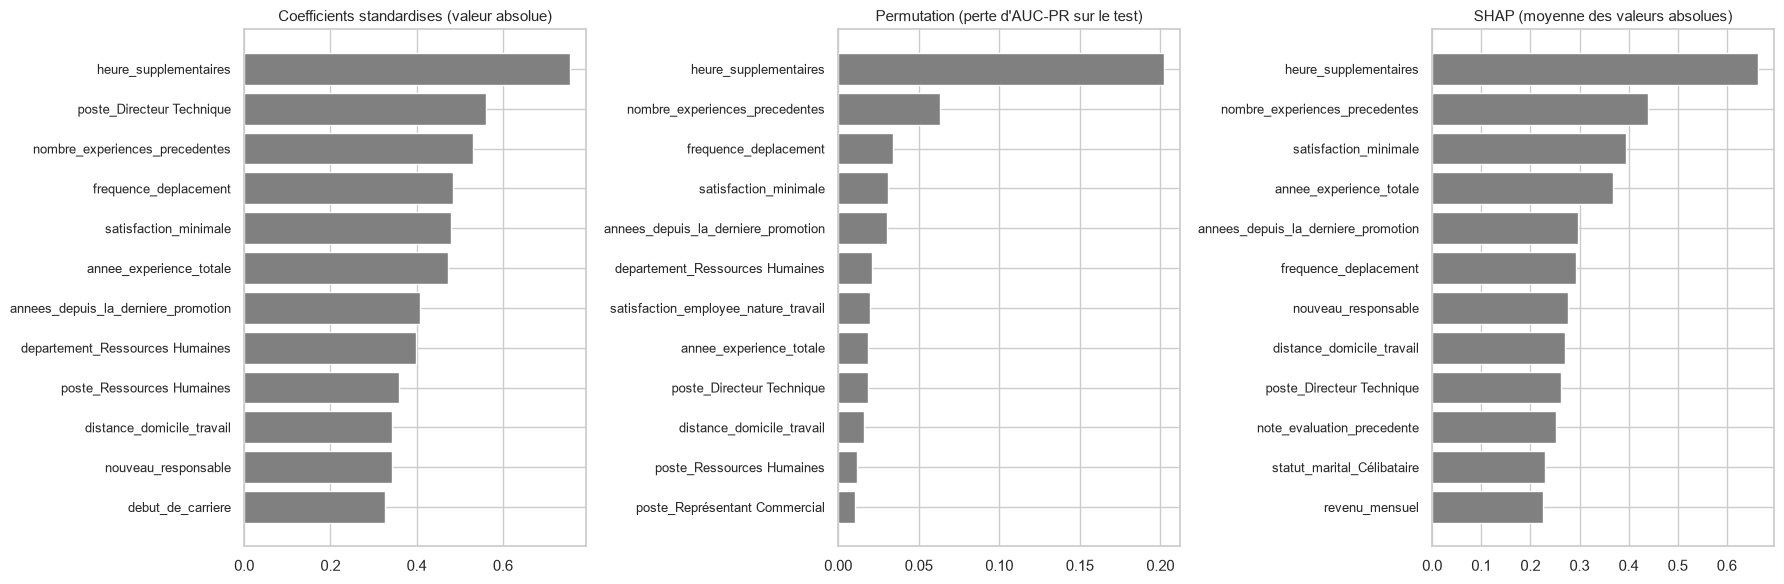

In [3]:
NB_FEATURES_AFFICHEES = 12

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (methode, titre) in zip(
    axes,
    [
        ("coefficient_absolu", "Coefficients standardises (valeur absolue)"),
        ("permutation", "Permutation (perte d'AUC-PR sur le test)"),
        ("shap_moyen_absolu", "SHAP (moyenne des valeurs absolues)"),
    ],
):
    sommet = importances[methode].sort_values().tail(NB_FEATURES_AFFICHEES)
    ax.barh(sommet.index, sommet.to_numpy(), color="grey")
    ax.set_title(titre, fontsize=11)
    ax.tick_params(axis="y", labelsize=9)
plt.tight_layout()
plt.show()

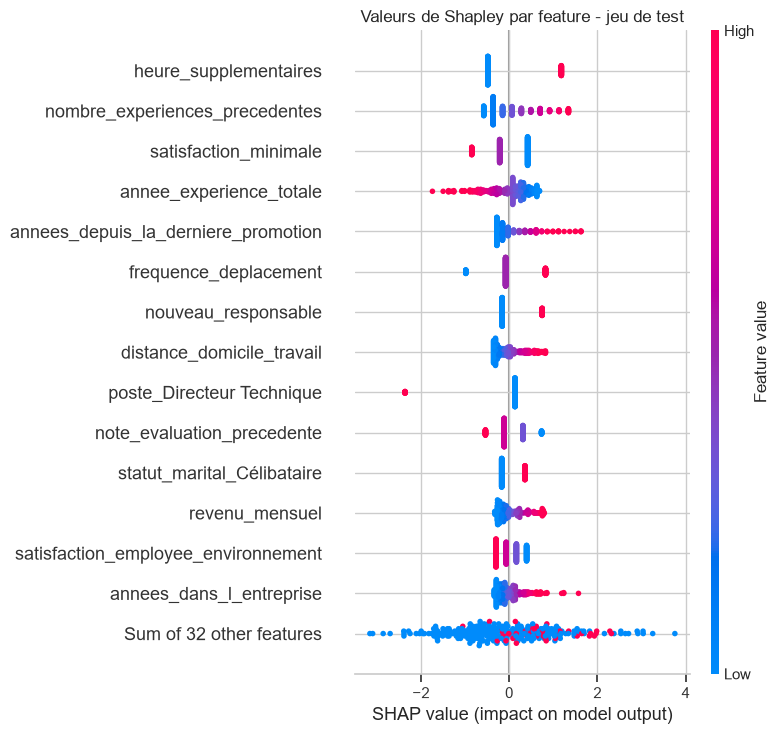

In [4]:
shap.plots.beeswarm(valeurs_shap, max_display=15, show=False)
plt.title("Valeurs de Shapley par feature - jeu de test")
plt.tight_layout()
plt.show()

**Ce que j'en retiens.**

**Les trois méthodes s'accordent sur le facteur n°1 : les heures supplémentaires.** Elles sont premières pour les coefficients (0,755), pour la permutation (perte de 0,202 d'AUC-PR, trois fois plus que la suivante) et pour SHAP (0,663). C'est le message le plus solide du projet : il ne dépend ni de la méthode de mesure, ni du modèle.

**Derrière, un groupe de cinq facteurs proches** (SHAP entre 0,293 et 0,440) : un grand nombre d'employeurs précédents, une satisfaction minimale basse, peu d'expérience professionnelle, une promotion ancienne et des déplacements fréquents. La permutation en place quatre aux rangs 2 à 5. Leur ordre exact n'a pas de sens ; leur présence en tête est solide.

**Les trois features créées au notebook 01 ne pèsent pas de la même façon.**
- `satisfaction_minimale` est au coeur du modèle : 3e pour SHAP, 4e pour la permutation.
- `nouveau_responsable` est 7e pour SHAP, et a **pris la place de la variable dont elle est issue** : le temps passé sous le responsable actuel, en années, tombe au 30e rang, avec un coefficient presque nul (-0,127). L'effet tient bien à la première année sous un nouveau responsable, pas à l'ancienneté auprès de lui.
- `debut_de_carriere` n'est que 17e pour SHAP, malgré un coefficient du même ordre (+0,326). Deux raisons : elle ne concerne que 8 % des collaborateurs, et SHAP mesure un effet moyen sur tous ; elle recoupe aussi largement `nouveau_responsable`, puisque 88 des 123 débutants ont changé de responsable dans l'année. Le modèle répartit l'effet « nouvel arrivant » entre ces deux indicateurs et l'expérience totale, qui monte au 4e rang. Son apport propre a été mesuré au notebook 02 : 1,5 point de précision moyenne en validation croisée.

**Le sens des effets se lit directement sur le signe des coefficients**, confirmé par le beeswarm (chaque point est un collaborateur, rouge pour une valeur élevée, bleu pour une valeur basse) :
- poussent vers le départ : les heures supplémentaires, un nombre élevé d'employeurs précédents, peu d'expérience et en particulier un début de carrière, une promotion ancienne, des déplacements fréquents, un changement de responsable dans l'année, un trajet long, le poste de consultant ;
- retiennent : une satisfaction minimale élevée, une forte augmentation de salaire récente, une bonne note d'évaluation précédente, le poste de directeur technique.

**Quatre divergences, qui s'expliquent :**
- **La permutation ne mesure pas `nouveau_responsable` sur le test** : elle lui donne une importance légèrement négative (-0,012), avec un écart-type plus grand que la valeur. Près d'un collaborateur sur cinq a changé de responsable dans l'année, et l'information est en partie portée aussi par `debut_de_carriere` : mélanger cette seule colonne sur 294 collaborateurs ne déplace que quelques cas, et l'effet se perd dans le bruit. Les coefficients et SHAP, qui mesurent l'effet sur chaque collaborateur concerné, la placent nettement plus haut.
- **Les coefficients surévaluent les catégories rares.** `poste_Directeur Technique` a le deuxième coefficient (-0,561), mais n'est que 9e pour SHAP. Un coefficient mesure l'effet pour un collaborateur concerné ; SHAP et la permutation mesurent l'effet sur l'ensemble des collaborateurs.
- **Le revenu a un coefficient positif (+0,276), à rebours des données brutes**, où le taux de départ baisse quand le salaire monte (section 3). Ce n'est pas un effet réel « plus de salaire, plus de départs » : le revenu est très corrélé à l'expérience totale (0,77), au poste de senior manager (0,62), à l'âge (0,50) et au poste de directeur technique (0,49). Une fois ces variables prises en compte, le modèle n'attribue au revenu qu'un effet résiduel, qui n'a pas de lecture métier. Je ne l'interprète donc pas isolément.
- **La participation au plan d'épargne entreprise n'arrive qu'au 26e rang SHAP**, alors que les partants y participent nettement moins. Les données l'expliquent : **aucun célibataire n'a jamais participé au plan d'épargne**, alors que 84 % des autres collaborateurs y ont participé au moins une fois. Les deux variables portent la même information, et la régression l'attribue au statut marital (11e rang SHAP). C'est un point de vigilance, traité dans les limites : le modèle s'appuie sur une variable sensible pour capter ce qui relève de l'engagement.

**À noter.** La valeur de base SHAP est de -0,998 en log-odds, soit environ 27 % de probabilité, au-dessus du taux réel de 16 % : c'est l'effet attendu de la pondération des classes. C'est pour cela que le seuil de décision (0,418) a été choisi sur des prédictions hors pli et non fixé à 0,5.

---
## 3. Comprendre le sens des valeurs de Shapley

**Question.** Comment la contribution d'une feature évolue-t-elle avec sa valeur, et cette forme correspond-elle à ce que montrent les données ?

**Méthode.** `shap.plots.scatter` place en abscisse la valeur de la feature et en ordonnée sa valeur de Shapley, pour chaque collaborateur. **Pour un modèle linéaire, chaque nuage est une droite** : la contribution est proportionnelle à l'écart à la moyenne, avec la même pente sur toute la plage de valeurs, et elle ne dépend d'aucune autre feature. La couleur, qui révélerait une interaction pour un modèle à base d'arbres, ne peut donc pas séparer les points ici.

Ces graphiques montrent la pente retenue par le modèle. Pour juger si cette simplification est acceptable, je la confronte ensuite aux **taux de départ observés** par tranche de valeur, sur les 1 470 collaborateurs : un effet de seuil marqué dans les données serait lissé en droite par le modèle.

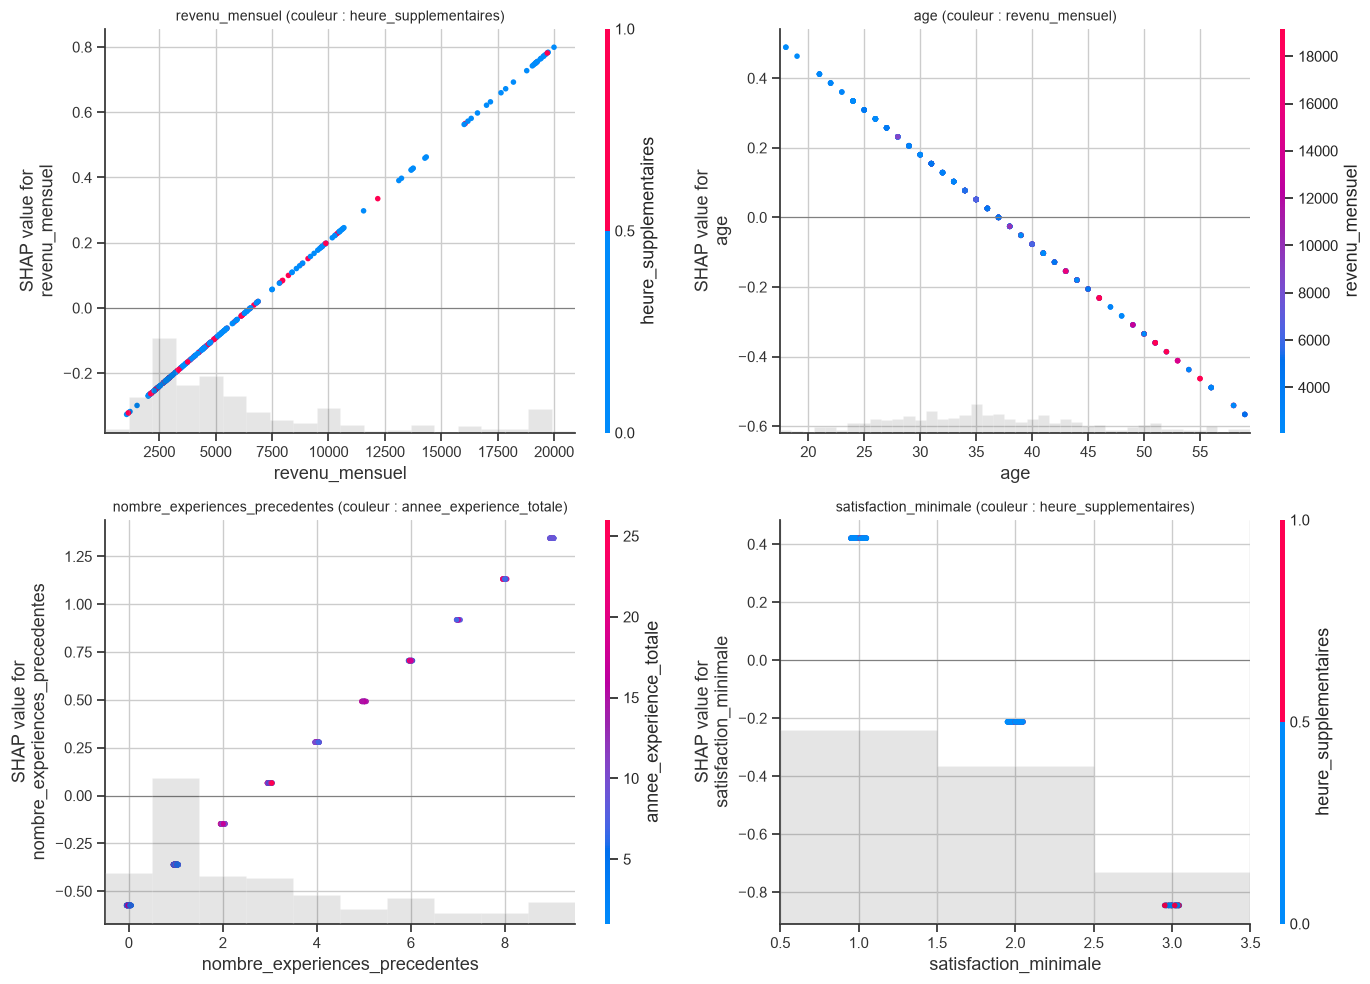

In [5]:
COUPLES_DEPENDANCE = [
    ("revenu_mensuel", "heure_supplementaires"),
    ("age", "revenu_mensuel"),
    ("nombre_experiences_precedentes", "annee_experience_totale"),
    ("satisfaction_minimale", "heure_supplementaires"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (feature, couleur) in zip(axes.ravel(), COUPLES_DEPENDANCE):
    shap.plots.scatter(
        valeurs_shap[:, feature], color=valeurs_shap[:, couleur], ax=ax, show=False
    )
    ax.axhline(0, color="grey", linewidth=0.8)
    ax.set_title(f"{feature} (couleur : {couleur})", fontsize=10)
plt.tight_layout()
plt.show()

In [6]:
# Taux de depart observes par tranche, sur tous les collaborateurs : la forme reelle de chaque effet
TRANCHES_OBSERVEES = {
    "revenu_mensuel": [0, 3000, 6000, np.inf],
    "age": [0, 25, 30, 35, 45, np.inf],
    "nombre_experiences_precedentes": [-1, 0, 1, 4, np.inf],
    "satisfaction_minimale": [0, 1, 2, 3, 4],
}
taux_observes = pd.concat(
    [
        y.groupby(pd.cut(X[feature], bornes), observed=True)
        .agg(collaborateurs="size", taux_depart="mean")
        .assign(feature=feature)
        for feature, bornes in TRANCHES_OBSERVEES.items()
    ]
)
taux_observes.index = taux_observes.index.astype(str)
display(taux_observes.set_index("feature", append=True).swaplevel().round(3))

collaborateurs  taux_depart
feature                                                                     
revenu_mensuel                 (0.0, 3000.0]                395        0.286
                               (3000.0, 6000.0]             519        0.127
                               (6000.0, inf]                556        0.104
age                            (0.0, 25.0]                  123        0.358
                               (25.0, 30.0]                 263        0.213
                               (30.0, 35.0]                 343        0.175
                               (35.0, 45.0]                 468        0.092
                               (45.0, inf]                  273        0.125
nombre_experiences_precedentes (-1.0, 0.0]                  197        0.117
                               (0.0, 1.0]                   521        0.188
                               (1.0, 4.0]                   444        0.110
                               (4.0, inf]                   308        0.218
satisfaction_minimale          (0.0, 1.0]                   737        0.212
                               (1.0, 2.0]                   500        0.122
                               (2.0, 3.0]                   227        0.088
                               (3.0, 4.0]                     6        0.000

**Ce que j'en retiens.**

**Pour ce modèle, chaque nuage est une droite** : la contribution d'une feature change de la même quantité à chaque unité, quelle que soit la valeur de départ, et la couleur ne sépare pas les points. Les taux observés montrent où cette simplification tient, et où elle coûte :
- **Satisfaction minimale : la droite colle aux données.** 21,2 % de départs quand au moins une dimension est à 1, 12,2 % à 2, 8,8 % à 3 : la baisse est régulière, la pente négative du modèle la décrit bien.
- **Âge : une bonne approximation.** De 35,8 % de départs jusqu'à 25 ans à 9,2 % entre 36 et 45 ans, la baisse est continue ; seule la légère remontée après 45 ans (12,5 %) échappe à la droite.
- **Revenu : un effet de seuil que la droite ne peut pas représenter.** 28,6 % de départs sous 3 000 € (395 collaborateurs), contre 12,7 % entre 3 000 et 6 000 € et 10,4 % au-delà : le risque se concentre sur les bas salaires, puis plafonne. Le modèle, qui de plus attribue cet effet au poste, à l'âge et à l'expérience (section 2), ne le restitue pas. Pour les RH, la zone salariale à surveiller vient donc des données brutes, pas du coefficient.
- **Nombre d'employeurs précédents : une forme en dents de scie.** 11,7 % de départs à 0, 18,8 % à 1, 11,0 % de 2 à 4, 21,8 % à partir de 5. La droite retient surtout le risque des parcours très mobiles. **La valeur 0 reste suspecte** : les 197 collaborateurs concernés ont tous exactement un an d'expérience de plus que leur ancienneté. Un « 0 » avec une année d'expérience ailleurs est incohérent : je signalerai ce point au métier, car le codage de cette variable est peut-être décalé d'une unité.

**Ce que coûte le choix d'un modèle linéaire, et comment je l'ai limité.** Il gagne en stabilité et en précision à rappel égal (notebook 02), mais il lisse les effets de seuil, comme celui du revenu. C'est précisément pour cela que `nouveau_responsable` et `debut_de_carriere` ont été créées : elles donnent au modèle, sous forme de colonnes binaires, les deux ruptures des premières années mises en évidence au notebook 01, qu'il ne pouvait pas trouver seul et qui ont un sens d'action pour le SIRH. Les leviers RH s'appuient donc sur les deux sources : le modèle pour le poids relatif des facteurs, les taux observés pour la forme de chaque effet.

---
## 4. Importance locale : expliquer une prédiction individuelle

**Question.** Pour un collaborateur donné, qu'est-ce qui pousse le modèle vers le départ ou vers le maintien ?

**Méthode.** Je choisis quatre collaborateurs du test, deux de chaque classe réelle, un par type de résultat au seuil retenu :

| Classe réelle | Prédiction correcte | Prédiction erronée |
|---|---|---|
| Départ | Vrai positif : départ détecté | Faux négatif : départ manqué |
| Reste | Vrai négatif : maintien prévu | Faux positif : fausse alerte |

Pour ne pas choisir des cas favorables, je prends dans chaque groupe le collaborateur **médian** en probabilité de départ. Le graphique en cascade part de la valeur de base (la prédiction moyenne) et empile les contributions : en rouge ce qui pousse vers le départ, en bleu ce qui retient.

In [7]:
depart_reel = y_test.to_numpy() == 1
depart_predit = predictions_test == 1
GROUPES = {
    "Vrai positif": depart_reel & depart_predit,
    "Faux negatif": depart_reel & ~depart_predit,
    "Vrai negatif": ~depart_reel & ~depart_predit,
    "Faux positif": ~depart_reel & depart_predit,
}


def position_mediane(masque: np.ndarray) -> int:
    """Position dans le test du collaborateur median en probabilite parmi le groupe."""
    positions = np.flatnonzero(masque)
    return int(positions[np.argsort(probabilites_test[positions])[len(positions) // 2]])


cas_retenus = {nom: position_mediane(masque) for nom, masque in GROUPES.items()}

COLONNES_PROFIL = [
    "id_employee",
    "age",
    "poste",
    "revenu_mensuel",
    "heure_supplementaires",
    "annees_dans_l_entreprise",
    "nombre_experiences_precedentes",
    "frequence_deplacement",
]
profils = df.loc[X_test.index[list(cas_retenus.values())], COLONNES_PROFIL]
profils.insert(0, "groupe", list(cas_retenus))
profils.insert(1, "effectif_groupe", [int(GROUPES[nom].sum()) for nom in cas_retenus])
profils.insert(2, "probabilite", probabilites_test[list(cas_retenus.values())].round(3))
display(profils.reset_index(drop=True))

,groupe,effectif_groupe,probabilite,id_employee,age,poste,revenu_mensuel,heure_supplementaires,annees_dans_l_entreprise,nombre_experiences_precedentes,frequence_deplacement
0,Vrai positif,36,0.808,331,32,Consultant,3730,Oui,3,0,Occasionnel
1,Faux negatif,11,0.284,780,33,Assistant de Direction,2686,Oui,10,1,Occasionnel
2,Vrai negatif,184,0.146,1177,26,Consultant,4420,Non,8,1,Occasionnel
3,Faux positif,63,0.603,1720,32,Assistant de Direction,3433,Non,5,6,Frequent


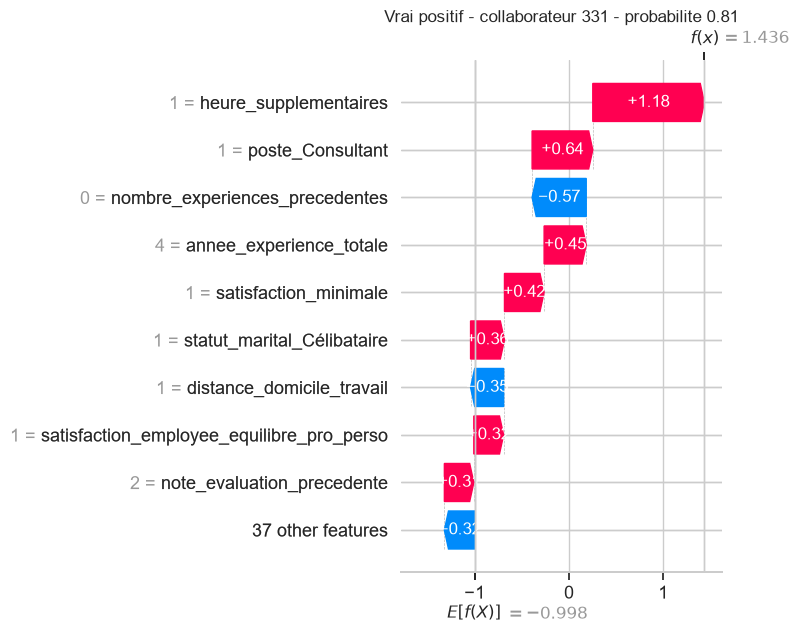

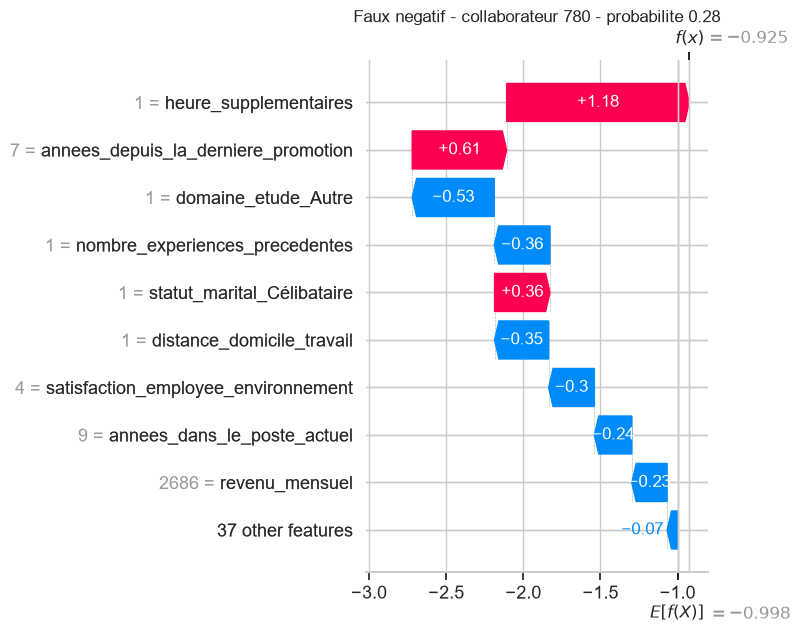

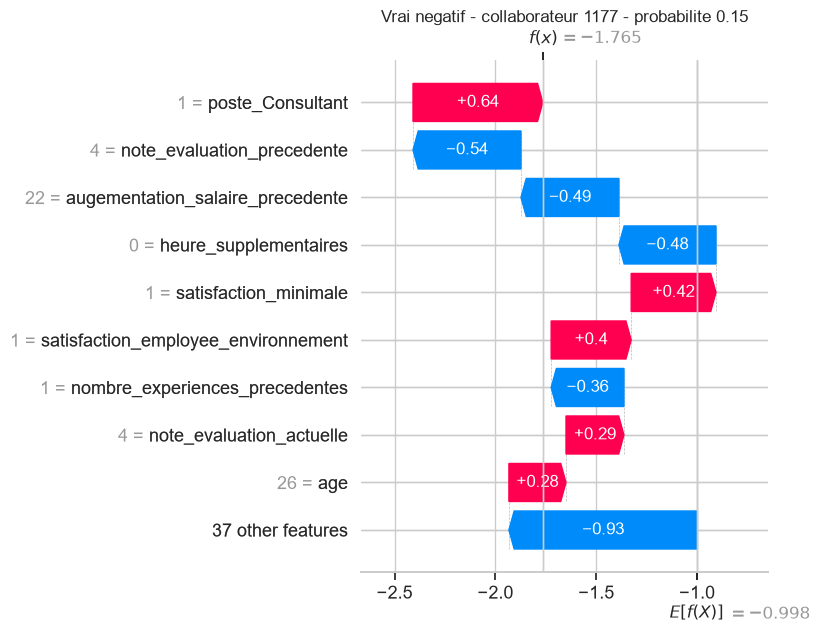

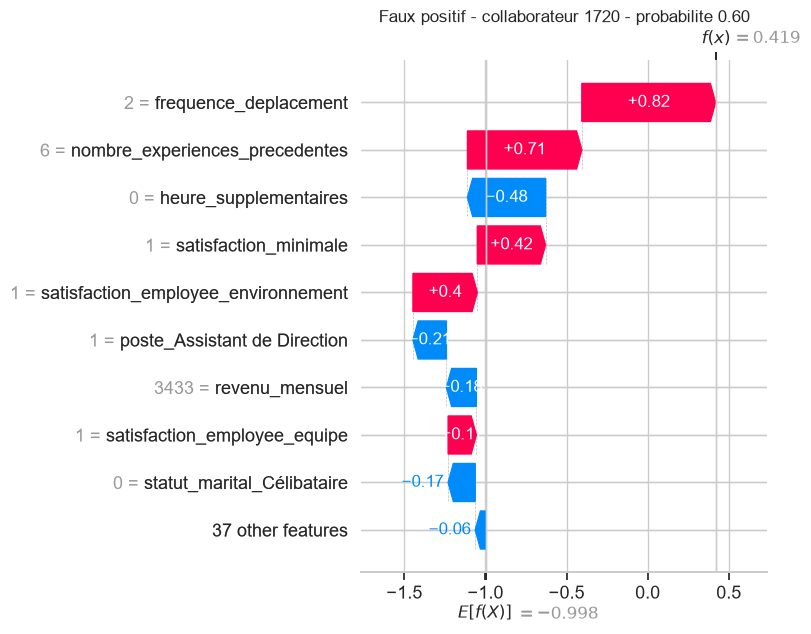

In [8]:
for nom, position in cas_retenus.items():
    shap.plots.waterfall(valeurs_shap[position], max_display=10, show=False)
    identifiant = df.loc[X_test.index[position], "id_employee"]
    plt.title(
        f"{nom} - collaborateur {identifiant} - probabilite {probabilites_test[position]:.2f}"
    )
    plt.tight_layout()
    plt.show()

**Ce que j'en retiens, cas par cas.** Chaque cascade part de la valeur de base (-0,998 en log-odds) : les barres rouges poussent vers le départ, les bleues retiennent. Sur le test, le modèle compte 36 vrais positifs, 11 faux négatifs, 184 vrais négatifs et 63 faux positifs.

**Vrai positif, départ détecté (collaborateur 331, probabilité 0,808).** Consultant de 32 ans, 3 730 € par mois, 3 ans d'ancienneté. Les heures supplémentaires (+1,18) dominent, renforcées par le poste de consultant (+0,64), une expérience totale courte (4 ans, +0,45) et une dimension de satisfaction au plus bas (+0,42). L'absence d'employeur précédent (-0,57) et un trajet d'un kilomètre (-0,35) retiennent, sans suffire. Pour un entretien de rétention, les sujets sont directement lisibles : charge de travail et point de satisfaction le plus bas.

**Faux négatif, départ manqué (collaborateur 780, probabilité 0,284).** Assistant de direction de 33 ans, 2 686 € par mois, 10 ans d'ancienneté. Les signaux de départ existaient : heures supplémentaires (+1,18) et 7 ans sans promotion (+0,61). Ils sont neutralisés par un domaine d'études « Autre » (-0,53), qui n'a pas de lecture métier, par un seul employeur précédent (-0,36), un trajet d'un kilomètre (-0,35) et une bonne satisfaction sur l'environnement de travail (-0,30). C'est une limite du modèle linéaire : un coefficient isolé, appris sur peu de collaborateurs, peut contrebalancer des signaux forts. Pour les RH, ce profil reste lisible : un collaborateur fidèle, en heures supplémentaires et sans évolution depuis 7 ans.

**Vrai négatif, maintien prévu (collaborateur 1177, probabilité 0,146).** Consultant de 26 ans, 4 420 € par mois, 8 ans d'ancienneté. Une très bonne évaluation précédente (-0,54), une forte augmentation récente (22 %, -0,49) et l'absence d'heures supplémentaires (-0,48) retiennent. Deux signaux de risque apparaissent pourtant : le poste de consultant (+0,64) et une satisfaction au plus bas sur l'environnement de travail, qui pèse deux fois, par cette note (+0,40) et par la satisfaction minimale (+0,42). Le modèle a raison sur la prédiction, mais l'insatisfaction sur l'environnement mérite un échange lors du prochain entretien annuel.

**Faux positif, fausse alerte (collaborateur 1720, probabilité 0,603).** Assistant de direction de 32 ans, 3 433 € par mois, 5 ans d'ancienneté, 6 employeurs précédents. Des déplacements fréquents (+0,82), un parcours très mobile (+0,71), une dimension de satisfaction au plus bas (+0,42) et une insatisfaction sur l'environnement de travail (+0,40) poussent vers le départ ; l'absence d'heures supplémentaires (-0,48) retient. L'alerte n'est pas absurde : un profil mobile, qui se déplace beaucoup et vit mal son environnement de travail, justifie un échange. Une partie des faux positifs sont des collaborateurs **à risque qui ne sont pas encore partis** : pour les RH, ce ne sont pas des entretiens perdus.

**Un signal à surveiller.** Le statut de célibataire pousse vers le départ dans deux des quatre cascades (+0,36). Comme vu en section 2, il porte surtout l'absence de participation au plan d'épargne. Une explication individuelle ne doit jamais le faire apparaître à un manager.

---
## 5. Synthèse métier : des features aux leviers RH

**Question.** Quelles causes de départ ressortent, et sur lesquelles les RH peuvent-ils agir ?

**Méthode.** Les colonnes issues du one-hot (`poste_Consultant`, `poste_Manager`...) découpent une même question en plusieurs colonnes. Pour un RH, seule compte la variable d'origine : j'additionne donc, pour chaque collaborateur, les valeurs de Shapley des colonnes d'une même variable, puis je fais la moyenne des valeurs absolues. J'associe ensuite chaque variable à un levier RH, en distinguant ce qui est actionnable de ce qui ne l'est pas. Ces leviers sont définis une seule fois, dans `config.LEVIERS_RH`, et partagés avec l'application métier (`src/application_metier.py`). Le tableau est exporté pour la présentation.

In [9]:
VARIABLES_NOMINALES = [
    colonne
    for colonne in df.columns
    if colonne not in X_test.columns
    and colonne not in (config.CIBLE, "id_employee")
    and not pd.api.types.is_numeric_dtype(df[colonne])
]


def variable_source(colonne: str) -> str:
    """Ramene une colonne one-hot a sa variable d'origine."""
    return next(
        (v for v in VARIABLES_NOMINALES if colonne.startswith(f"{v}_")), colonne
    )


shap_par_colonne = pd.DataFrame(valeurs_shap.values, columns=X_test.columns)
shap_par_variable = shap_par_colonne.T.groupby(variable_source).sum().T
importance_variables = (
    shap_par_variable.abs()
    .mean()
    .sort_values(ascending=False)
    .rename("importance_shap")
)

synthese = importance_variables.head(15).to_frame()
synthese["levier_rh"] = [
    config.LEVIERS_RH.get(v, config.LEVIER_PAR_DEFAUT)[0]
    for v in synthese.index
]
synthese["actionnable"] = [config.LEVIERS_RH.get(v, config.LEVIER_PAR_DEFAUT)[1] for v in synthese.index]
synthese.index.name = "variable"
display(synthese.round(3))

synthese.to_csv(config.FICHIER_FACTEURS_ACTIONS)
print(f"Synthese exportee : {config.FICHIER_FACTEURS_ACTIONS}")

,importance_shap,levier_rh,actionnable
variable,,,
poste,0.739,Parcours par metier : cibler les postes les pl...,True
heure_supplementaires,0.663,Charge de travail : limiter et repartir les he...,True
nombre_experiences_precedentes,0.440,Non actionnable : delimite la population a suivre,False
satisfaction_minimale,0.394,Suivi de la satisfaction : traiter le point de...,True
annee_experience_totale,0.369,Non actionnable : delimite la population a suivre,False
statut_marital,0.336,Non actionnable : delimite la population a suivre,False
annees_depuis_la_derniere_promotion,0.296,Evolution de carriere et promotions,True
frequence_deplacement,0.293,Organisation du travail : limiter les deplacem...,True
nouveau_responsable,0.277,Stabilite du management : accompagner chaque c...,True


Synthese exportee : C:\Users\Windows 11\Desktop\AI_Engineer\P4_Classification_rh\reports\facteurs_actions.csv


**Ce que j'en retiens : les causes de départ, et ce que les RH peuvent en faire.**

**Les leviers prioritaires :**
1. **Heures supplémentaires** (facteur n°1 des trois méthodes). 416 collaborateurs en font, avec 30,5 % de départs contre 10,4 % pour les autres. Levier : suivre, plafonner et mieux répartir la charge.
2. **Satisfaction au plus bas sur une dimension** (4e variable). Un seul point de rupture suffit à faire monter le risque. Levier : exploiter le sondage annuel pour déclencher un échange dès qu'une dimension est notée 1, sans attendre que toutes se dégradent.
3. **Les premières années : début de carrière et nouveau responsable.** Le modèle combine l'expérience totale (5e variable), `nouveau_responsable` (9e) et `debut_de_carriere`. Les données sont nettes : 43,9 % de départs chez les 123 collaborateurs qui ont 2 ans d'expérience ou moins, 32,3 % chez les 263 qui ont changé de responsable dans l'année, contre 13 % environ pour les autres. Les deux situations se recoupent souvent : 88 des 123 débutants ont aussi un nouveau responsable. C'est le levier le plus directement pilotable par le SIRH, qui connaît ces deux informations dès qu'elles changent : parcours d'intégration et de fidélisation des débutants, point de suivi après chaque changement de responsable.
4. **Perspectives d'évolution** (7e variable). Une promotion ancienne pousse vers le départ. Levier : revue régulière des parcours et des promotions.
5. **Trajets et déplacements** (8e et 10e variables). Levier : télétravail pour les trajets longs, limitation des déplacements fréquents.
6. **Le métier.** Le poste est la première variable une fois ses colonnes regroupées : les consultants, les représentants commerciaux et les postes RH sont les plus exposés, les directeurs techniques et les managers les moins. Levier : concentrer les actions sur les métiers les plus exposés.

**Le salaire reste un sujet, mais pas à travers le coefficient.** Le revenu n'arrive qu'au 12e rang, et son coefficient n'a pas de lecture métier (section 2). Les données brutes montrent en revanche un risque nettement plus élevé sous 3 000 € par mois (28,6 % de départs) : la revue ciblée des bas de grille reste une piste, à justifier par ces taux observés.

**Ce qui n'est pas un levier mais délimite la population à suivre.** Le nombre d'employeurs précédents (3e variable), l'âge et le département décrivent un profil mobile et peu expérimenté plus exposé. Les RH ne pilotent pas ces variables, mais elles indiquent où concentrer les efforts.

**Le statut marital ne doit pas être lu comme une cause.** Il arrive au 6e rang des variables, parce qu'il porte l'information de la participation au plan d'épargne : aucun célibataire n'y a jamais participé. Il ne peut ni motiver une action individuelle ni figurer sur une fiche de risque.

Ces facteurs rejoignent ceux de l'analyse exploratoire du notebook 01 (heures supplémentaires, bas salaires, profil junior, déplacements, satisfaction). Le modèle confirme ces constats et en mesure le poids respectif, une fois toutes les variables prises en compte ensemble.

---
## 6. Limites de l'interprétation

- **Association, pas causalité.** SHAP explique ce que fait le modèle, pas ce qui se passe dans l'entreprise. Qu'une feature pousse la prédiction vers le départ ne prouve pas qu'agir dessus retiendra le collaborateur. Les leviers proposés sont des pistes à tester, par exemple sur une population pilote.
- **Effets linéaires.** Le modèle retenu attribue à chaque feature un effet constant sur toute sa plage de valeurs. Il lisse les effets de seuil, comme celui des bas salaires : la forme de chaque effet se lit dans les taux observés, pas dans le modèle (section 3). Seules les ruptures des premières années, sous un nouveau responsable et en début de carrière, lui sont données explicitement, par `nouveau_responsable` et `debut_de_carriere`.
- **Features corrélées.** Âge, expérience, anciennetés et revenu portent une information proche (notebook 01, section 15), et les deux indicateurs des premières années se recoupent. Dans une régression, les coefficients de variables corrélées sont instables, et l'un d'eux peut changer de signe, comme celui du revenu : je lis ces variables comme des blocs plutôt qu'une par une.
- **Données d'une seule période.** Le sondage est annuel et les données décrivent une photographie. Le modèle devra être réentraîné et réinterprété à chaque nouvelle campagne.
- **Variables sensibles.** Le statut marital pèse dans le modèle (6e variable), parce qu'il porte l'information de la participation au plan d'épargne. Le genre et le statut marital ne doivent jamais motiver une décision individuelle ni apparaître sur une fiche de risque remise à un manager. Avant toute mise en service, je recommande de mesurer les performances du modèle sans ces variables (`config.COLONNES_SENSIBLES`) : si elles restent comparables, c'est cette version qu'il faudrait déployer.